# CNN + Network Activation Visualization

Comprehensive visualization of the vision CNN and network internals during
a gap-jumping rollout. Loads the trained `shared_vision_task_obs` checkpoint
and extracts per-timestep activations at every layer.

**Architecture (feedforward, no RNN):**
```
vision (32x32x1) -> VisionEncoder CNN [4,8,16,32] -> 32-dim features
[features, task_obs(54)] -> Fusion MLP [256,256,256] -> latent z (16-dim)
[z] -> Decoder MLP [512,512,512] -> action params
```

**Contents:**
1. Rollout video with third-person view + egocentric vision overlay
2. Rollout filmstrip with vision overlay
3. Temporal activation heatmaps (CNN features, fusion MLP, latent z) with gap annotations
4. Gap-correlated CNN feature identification (top 5 features by Pearson r)
5. Video: CNN gap rollout with spatial activation heatmaps
6. Video: Latent z PCA trajectory (3D) colored by gap proximity
7. Video: CNN features PCA trajectory (3D) colored by gap proximity

In [1]:
import os

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.5"
os.environ["MUJOCO_GL"] = "egl"
os.environ["PYOPENGL_PLATFORM"] = "egl"

import gc
import json
import jax
import jax.numpy as jnp
import numpy as np
import mujoco
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Rectangle
from pathlib import Path
from omegaconf import OmegaConf
from scipy import stats

from track_mjx.agent import checkpointing
from track_mjx.agent.ff_ppo import ppo_networks as ff_ppo_networks
from track_mjx.agent.ff_ppo.vision_encoder import VisionEncoder
from track_mjx.agent.ff_ppo.shared_vision_network import SharedVisionPolicyValueModule
from track_mjx.agent.observation_utils import (
    get_obs_sizes,
    init_dict_normalizer,
    normalize_dict_obs,
)
from track_mjx.agent.checkpointing import _replace_zero_sized_arrays
from vnl_playground import tasks
from vnl_playground.tasks.wrappers import HighLevelWrapper
from vnl_playground.tasks.rodent.vision_jax import JaxVisionRenderer
from mujoco.mjx.warp.types import DATA_NON_VMAP
import orbax.checkpoint as ocp

print(f"JAX devices: {jax.devices()}")
print(f"JAX backend: {jax.default_backend()}")

JAX devices: [CudaDevice(id=0)]
JAX backend: gpu


## Configuration

In [2]:
CHECKPOINT_DIR = Path(
    "/home/talmolab/Desktop/SalkResearch/vnl-playground/"
    "highlvl_checkpoints/260215_091930_last10"
)
MIMIC_CHECKPOINT_DIR = Path(
    "/home/talmolab/Desktop/SalkResearch/track-mjx/model_checkpoints"
)

EPISODE_LENGTH = 500
SEED = 42
VIDEO_FPS = 50
VIDEO_HEIGHT = 480
VIDEO_WIDTH = 640

## Load Config, Decoder, Environment, Network, Checkpoint

In [3]:
# Load checkpoint config
with open(CHECKPOINT_DIR / "config.json") as f:
    cfg_dict = json.load(f)
cfg = OmegaConf.create(cfg_dict)

# Load frozen decoder
mimic_ckpt_path = str(MIMIC_CHECKPOINT_DIR / cfg.transfer.mimic_run_id)
mimic_cfg = OmegaConf.create(checkpointing.load_config_from_checkpoint(mimic_ckpt_path))
decoder_policy_fn = ff_ppo_networks.make_decoder_policy_fn(mimic_ckpt_path)
latent_size = mimic_cfg.network_config.intention_size

# Load environment
env_args = (
    OmegaConf.to_container(cfg.env_config.get("env_args", {}), resolve=True) or {}
)
if hasattr(mimic_cfg, "env_config") and hasattr(mimic_cfg.env_config, "ctrl_dt"):
    env_args["ctrl_dt"] = float(mimic_cfg.env_config.ctrl_dt)
raw_env = tasks.load(
    cfg.env_config.env_name,
    flatten_obs=False,
    config_overrides=env_args if env_args else None,
)

# Get obs_sizes
highlvl_obs_key = cfg.transfer.get("highlvl_obs_key", "imitation_target")
decoder_obs_key = cfg.transfer.get("decoder_obs_key", "proprioception")
_tmp = HighLevelWrapper(
    raw_env,
    decoder_policy_fn,
    latent_size,
    highlvl_obs_key=highlvl_obs_key,
    decoder_obs_key=decoder_obs_key,
    pass_vision=True,
    pass_task_obs=True,
)
_tmp_state = _tmp.reset(jax.random.PRNGKey(99))
obs_sizes = get_obs_sizes(_tmp_state.obs)
del _tmp, _tmp_state

print(f"Environment: {cfg.env_config.env_name}")
print(f"Latent size: {latent_size}")
print(f"Obs sizes: {obs_sizes}")

Warp 1.11.0 initialized:
   CUDA Toolkit 12.9, Driver 13.1
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA RTX A5000" (24 GiB, sm_86, mempool enabled)
   Kernel cache:
     /home/talmolab/.cache/warp/1.11.0
Warp DeprecationWarning: The symbol `warp.types.warp_type_to_np_dtype` will soon be removed from the public API. It can still be accessed from `warp._src.types.warp_type_to_np_dtype` but might be changed or removed without notice.
Module mujoco.mjx.third_party.mujoco_warp._src.smooth 9d8c26b load on device 'cuda:0' took 6.90 ms  (cached)
Module mujoco.mjx.third_party.mujoco_warp._src.collision_driver de6dc98 load on device 'cuda:0' took 0.34 ms  (cached)
Module _nxn_broadphase__locals__kernel_1021a65a 1021a65 load on device 'cuda:0' took 0.39 ms  (cached)
Module ccd_kernel_builder__locals__ccd_kernel_ca1e5829 ca1e582 load on device 'cuda:0' took 1.07 ms  (cached)
Module ccd_kernel_builder__locals__ccd_kernel_c6def0bf c6def0b load on device 'cuda:0' took 1.61 ms  (ca

In [4]:
# Recreate PPO network
vision_shape = (
    cfg.env_config.get("vision_height", 32),
    cfg.env_config.get("vision_width", 32),
    1 if cfg.env_config.get("grayscale", True) else 3,
)

ppo_network, shared_module = (
    ff_ppo_networks.make_shared_vision_task_obs_highlvl_ppo_networks(
        obs_sizes=obs_sizes,
        action_size=latent_size,
        vision_shape=vision_shape,
        vision_latent_size=cfg.network_config.vision_latent_size,
        vision_feature_size=cfg.network_config.get("vision_feature_size", 32),
        decoder_hidden_layer_sizes=tuple(cfg.network_config.decoder_hidden_layer_sizes),
        value_hidden_layer_sizes=tuple(cfg.network_config.value_hidden_layer_sizes),
        vision_channels=tuple(cfg.network_config.vision_channels),
        fusion_hidden_layer_sizes=tuple(
            cfg.network_config.get("fusion_hidden_layer_sizes", [256])
        ),
    )
)

# Load policy from checkpoint
ckpt_mgr = ocp.CheckpointManager(
    str(CHECKPOINT_DIR),
    options=ocp.CheckpointManagerOptions(
        save_interval_steps=1,
        max_to_keep=200,
        step_prefix="PPONetwork",
        create=False,
    ),
)
latest_step = ckpt_mgr.latest_step()

key_policy, _ = jax.random.split(jax.random.PRNGKey(0))
init_policy_params = ppo_network.policy_network.init(key_policy)
dummy_obs = {
    "imitation_target": jnp.zeros((1, obs_sizes["imitation_target"])),
    "proprioception": jnp.zeros((1, obs_sizes["proprioception"])),
}
abstract_policy = _replace_zero_sized_arrays(
    (init_dict_normalizer(dummy_obs), init_policy_params)
)

normalizer_params, policy_params = ckpt_mgr.restore(
    latest_step,
    args=ocp.args.Composite(policy=ocp.args.StandardRestore(abstract_policy)),
)["policy"]
params_tuple = (normalizer_params, policy_params)

print(f"Loaded checkpoint step {latest_step}")
print(f"Architecture: {cfg.network_config.arch_name}")
print(f"Vision shape: {vision_shape}")

Loaded checkpoint step 99
Architecture: shared_vision_task_obs
Vision shape: (32, 32, 1)


## Set Up Eval Pipeline

In [5]:
gc.collect()
jax.clear_caches()


def _add_batch_dim_for_warp(data):
    """Add leading batch dim to Data, skipping non-vmap fields."""

    def _maybe_expand(path, x):
        parts = [p.name for p in path if hasattr(p, "name") and p.name != "_impl"]
        attr = "__".join(parts)
        if attr in DATA_NON_VMAP:
            return x
        return x[None, ...]

    return jax.tree.map_with_path(_maybe_expand, data)


# Vision renderer
vision_renderer = JaxVisionRenderer(
    mj_model=raw_env.mj_model,
    mjx_model=raw_env.mjx_model,
    nworld=1,
    width=cfg.env_config.get("vision_width", 32),
    height=cfg.env_config.get("vision_height", 32),
    grayscale=cfg.env_config.get("grayscale", True),
    camera_name=cfg.env_config.get("vision_camera_name", "egocentric-rodent"),
)

# HighLevelWrapper
eval_env = HighLevelWrapper(
    raw_env,
    decoder_policy_fn,
    latent_size,
    highlvl_obs_key=highlvl_obs_key,
    decoder_obs_key=decoder_obs_key,
    pass_vision=True,
    pass_task_obs=True,
)


def eval_reset(rng):
    state = eval_env.reset(rng)
    data_b = _add_batch_dim_for_warp(state.data)
    vision = vision_renderer.render(data_b)[0]
    return state.replace(obs={**state.obs, "vision": vision})


def eval_step(state, action):
    state = eval_env.step(state, action)
    data_b = _add_batch_dim_for_warp(state.data)
    vision = vision_renderer.render(data_b)[0]
    return state.replace(obs={**state.obs, "vision": vision})


# JIT compile
make_logging_policy = ff_ppo_networks.make_logging_inference_fn(ppo_network)
jit_inference_fn = jax.jit(make_logging_policy(deterministic=True))
jit_eval_reset = jax.jit(eval_reset)
jit_eval_step = jax.jit(eval_step)

print("Eval pipeline ready.")

Module update_gradient_JTDAJ_sparse_tiled__locals__kernel_9c904022 398f3d2 load on device 'cuda:0' took 40.70 ms  (cached)
Module mujoco.mjx.third_party.mujoco_warp._src.io db47b00 load on device 'cuda:0' took 1.86 ms  (cached)
Module mujoco.mjx.third_party.mujoco_warp._src.bvh 6d8d8a8 load on device 'cuda:0' took 0.91 ms  (cached)
Eval pipeline ready.


## Define Activation Extraction Functions

In [6]:
# Standalone vision encoder for manual activation extraction
standalone_encoder = VisionEncoder(
    feature_size=cfg.network_config.get("vision_feature_size", 32),
    channels=tuple(cfg.network_config.vision_channels),
)
vision_encoder_params = {"params": policy_params["params"]["vision_encoder"]}

CHANNELS = tuple(cfg.network_config.vision_channels)
STRIDES = (1, 1, 2, 2)
FUSION_LAYERS = tuple(cfg.network_config.get("fusion_hidden_layer_sizes", [256]))


def get_conv_activations(image):
    """Extract per-layer spatial conv activations from VisionEncoder.

    Returns list of numpy arrays, one per conv layer.
    Each has shape (H_i, W_i, C_i).
    """
    x = jnp.array(image).reshape(1, *image.shape[-3:])
    layer_acts = []
    params = vision_encoder_params["params"]
    for i, (ch, stride) in enumerate(zip(CHANNELS, STRIDES)):
        kernel = params[f"conv_{i}"]["kernel"]
        bias = params[f"conv_{i}"]["bias"]
        x = (
            jax.lax.conv_general_dilated(
                x,
                kernel,
                window_strides=(stride, stride),
                padding="VALID",
                dimension_numbers=("NHWC", "HWIO", "NHWC"),
            )
            + bias
        )
        x = jax.nn.relu(x)
        layer_acts.append(np.array(x[0]))
    return layer_acts


def get_all_activations(obs_dict):
    """Extract all network activations from a single observation.

    Returns dict with:
        - cnn_features: (32,) CNN output vector
        - fusion_hiddens: list of (256,) arrays, one per fusion layer
        - latent_z: (16,) intention vector
        - decoder_hiddens: dict of per-layer decoder activations
    """
    obs_b = {k: jnp.array(np.array(v))[None, ...] for k, v in obs_dict.items()}
    obs_normed = normalize_dict_obs(obs_b, normalizer_params)

    # Full forward with activation extraction
    action, latent_mean, latent_logvar, acts = shared_module.apply(
        policy_params,
        obs=obs_normed,
        key=jax.random.PRNGKey(0),
        get_activation=True,
        method="policy_forward",
    )

    # Extract fusion MLP hidden activations manually
    params = policy_params["params"]
    task_obs = obs_normed["imitation_target"]
    vision = obs_normed["vision"]
    vision_features = standalone_encoder.apply(vision_encoder_params, vision)

    combined = jnp.concatenate([vision_features, task_obs], axis=-1)
    z = combined
    fusion_hiddens = []
    for i in range(len(FUSION_LAYERS)):
        kernel = params[f"fusion_dense_{i}"]["kernel"]
        bias = params[f"fusion_dense_{i}"]["bias"]
        z = jax.nn.silu(z @ kernel + bias)
        ln_scale = params[f"fusion_norms_{i}"]["scale"]
        ln_bias = params[f"fusion_norms_{i}"]["bias"]
        mean = jnp.mean(z, axis=-1, keepdims=True)
        var = jnp.var(z, axis=-1, keepdims=True)
        z = (z - mean) / jnp.sqrt(var + 1e-5) * ln_scale + ln_bias
        fusion_hiddens.append(np.array(z[0]))

    return {
        "cnn_features": np.array(acts["vision_features"][0]),
        "fusion_hiddens": fusion_hiddens,
        "latent_z": np.array(acts["intention"][0]),
        "decoder_hiddens": {k: np.array(v[0]) for k, v in acts["decoder"].items()},
        "task_obs": np.array(acts["task_obs"][0]),
    }


# Test it
test_state = jit_eval_reset(jax.random.PRNGKey(0))
test_acts = get_all_activations(test_state.obs)
print(f"CNN features: {test_acts['cnn_features'].shape}")
print(f"Fusion hiddens: {[h.shape for h in test_acts['fusion_hiddens']]}")
print(f"Latent z: {test_acts['latent_z'].shape}")
print(
    f"Decoder hiddens: {[(k, v.shape) for k, v in test_acts['decoder_hiddens'].items()]}"
)
del test_state, test_acts

Module render__locals___render_megakernel_77adab5d 77adab5 load on device 'cuda:0' took 1.00 ms  (cached)
CNN features: (32,)
Fusion hiddens: [(256,), (256,), (256,)]
Latent z: (16,)
Decoder hiddens: [('layer_0', (512,)), ('layer_1', (512,)), ('layer_2', (512,))]


## Run Full Rollout with Activation Recording

In [7]:
eval_rng = jax.random.PRNGKey(SEED)
state = jit_eval_reset(eval_rng)
act_rng = jax.random.PRNGKey(SEED + 1)

# Storage
qpos_list = [np.array(state.data.qpos)]
ego_frames = [np.array(state.obs["vision"])]
rewards = []
cnn_features_traj = []
fusion0_traj = []  # First fusion layer (closest to CNN)
fusion_last_traj = []  # Last fusion layer (closest to latent z)
latent_z_traj = []
task_obs_traj = []

# Conv spatial maps at sampled timesteps (every 25 steps)
conv_sample_interval = 25
conv_spatial_maps = {}  # step -> list of conv layer activations

# Extract activations for step 0
acts_0 = get_all_activations(state.obs)
cnn_features_traj.append(acts_0["cnn_features"])
fusion0_traj.append(acts_0["fusion_hiddens"][0])
fusion_last_traj.append(acts_0["fusion_hiddens"][-1])
latent_z_traj.append(acts_0["latent_z"])
task_obs_traj.append(acts_0["task_obs"])
conv_spatial_maps[0] = get_conv_activations(state.obs["vision"])

# Extract rodent x-position from qpos
# For the gap env, the torso body x-position indicates corridor progress.
# qpos layout depends on whether randomize_gaps is enabled (adds slide joints).
# We use the info dict or directly extract from data.
rodent_x_positions = [float(state.data.qpos[raw_env._rodent_qpos_start - 7])]

print(f"Running rollout ({EPISODE_LENGTH} steps) with full activation recording...")
for i in range(EPISODE_LENGTH):
    _, act_rng = jax.random.split(act_rng)
    action, extras = jit_inference_fn(params_tuple, state.obs, act_rng)
    state = jit_eval_step(state, action)

    # Record basic data
    qpos_list.append(np.array(state.data.qpos))
    ego_frames.append(np.array(state.obs["vision"]))
    rewards.append(float(state.reward))
    rodent_x_positions.append(float(state.data.qpos[raw_env._rodent_qpos_start - 7]))

    # Extract activations
    acts = get_all_activations(state.obs)
    cnn_features_traj.append(acts["cnn_features"])
    fusion0_traj.append(acts["fusion_hiddens"][0])
    fusion_last_traj.append(acts["fusion_hiddens"][-1])
    latent_z_traj.append(acts["latent_z"])
    task_obs_traj.append(acts["task_obs"])

    # Conv spatial maps at sampled steps
    if (i + 1) % conv_sample_interval == 0:
        conv_spatial_maps[i + 1] = get_conv_activations(state.obs["vision"])

    if (i + 1) % 100 == 0:
        print(f"  Step {i+1}/{EPISODE_LENGTH}, cum_reward={sum(rewards):.2f}")

# Convert to arrays
cnn_features_traj = np.array(cnn_features_traj)  # (T+1, 32)
fusion0_traj = np.array(fusion0_traj)  # (T+1, 256)
fusion_last_traj = np.array(fusion_last_traj)  # (T+1, 256)
latent_z_traj = np.array(latent_z_traj)  # (T+1, 16)
task_obs_traj = np.array(task_obs_traj)  # (T+1, 54)
rodent_x_positions = np.array(rodent_x_positions)

total_reward = sum(rewards)
print(f"\nDone. Total reward: {total_reward:.2f}")
print(f"Mean step reward: {np.mean(rewards):.4f}")
print(
    f"Rodent x-range: [{rodent_x_positions.min():.2f}, {rodent_x_positions.max():.2f}]"
)
print(f"Stored {len(ego_frames)} frames, {len(conv_spatial_maps)} conv map samples")

Running rollout (500 steps) with full activation recording...
  Step 100/500, cum_reward=35.48
  Step 200/500, cum_reward=73.78
  Step 300/500, cum_reward=110.81
  Step 400/500, cum_reward=147.93
  Step 500/500, cum_reward=182.25

Done. Total reward: 182.25
Mean step reward: 0.3645
Rodent x-range: [0.50, 4.17]
Stored 501 frames, 21 conv map samples


## Rollout Video: Third-Person + Vision Overlay

Quick video showing the full rollout with egocentric vision overlaid on the third-person view.

In [8]:
from matplotlib.animation import FFMpegWriter
from IPython.display import Video, display

# Third-person renderer setup
mj_model = raw_env.mj_model
mj_data = mujoco.MjData(mj_model)
mj_renderer = mujoco.Renderer(mj_model, height=VIDEO_HEIGHT, width=VIDEO_WIDTH)

camera = mujoco.MjvCamera()
camera.type = mujoco.mjtCamera.mjCAMERA_TRACKING
for name in ["torso-rodent", "torso"]:
    try:
        camera.trackbodyid = mj_model.body(name).id
        break
    except Exception:
        continue
camera.distance = 1.0
camera.azimuth = 90
camera.elevation = -20
camera.lookat[:] = [0, 0, 0.3]


def render_third_person(qpos):
    """Render a third-person frame from qpos."""
    mj_data.qpos = qpos
    mujoco.mj_forward(mj_model, mj_data)
    mj_renderer.update_scene(mj_data, camera)
    return mj_renderer.render().copy()


def overlay_ego(frame, ego_img, scale=3):
    """Overlay scaled egocentric image on upper-left of frame."""
    img = (np.clip(ego_img, 0, 1) * 255).astype(np.uint8)
    if img.ndim == 2:
        img = img[:, :, None]
    if img.shape[-1] == 1:
        img = np.repeat(img, 3, axis=-1)
    img = np.repeat(np.repeat(img, scale, axis=0), scale, axis=1)
    sh, sw = img.shape[:2]
    pad = 3
    y0, x0 = pad + 4, pad + 4
    y1, x1 = y0 + sh, x0 + sw
    out = frame.copy()
    if y1 + pad < out.shape[0] and x1 + pad < out.shape[1]:
        out[y0 - pad : y1 + pad, x0 - pad : x1 + pad] = 255
        out[y0:y1, x0:x1] = img
    return out


ROLLOUT_VIDEO_PATH = str(CHECKPOINT_DIR.parent / "rollout_overview.mp4")

fig_ro, ax_ro = plt.subplots(1, 1, figsize=(8, 6), dpi=100)
im_ro = ax_ro.imshow(np.zeros((VIDEO_HEIGHT, VIDEO_WIDTH, 3), dtype=np.uint8))
ax_ro.axis("off")
title_ro = ax_ro.set_title("", fontsize=11, fontweight="bold")
fig_ro.tight_layout()

print(f"Rendering rollout overview video ({len(qpos_list)} frames)...")
vid_writer = FFMpegWriter(fps=VIDEO_FPS)
with vid_writer.saving(fig_ro, ROLLOUT_VIDEO_PATH, dpi=100):
    for t in range(len(qpos_list)):
        frame = render_third_person(qpos_list[t])
        frame = overlay_ego(frame, ego_frames[t], scale=4)
        im_ro.set_data(frame)
        title_ro.set_text(f"Step {t}/{EPISODE_LENGTH}")
        vid_writer.grab_frame()
        if (t + 1) % 100 == 0:
            print(f"  {t+1}/{len(qpos_list)} frames")

plt.close(fig_ro)
print(f"Video saved: {ROLLOUT_VIDEO_PATH}")

Rendering rollout overview video (501 frames)...
  100/501 frames
  200/501 frames
  300/501 frames
  400/501 frames
  500/501 frames
Video saved: /home/talmolab/Desktop/SalkResearch/vnl-playground/highlvl_checkpoints/rollout_overview.mp4


In [ ]:
display(Video(ROLLOUT_VIDEO_PATH, embed=True, width=640))

## Extract Gap Positions from Environment

Identify where the gaps are in the corridor so we can correlate features with gap proximity.

In [10]:
# Extract gap geometry from the environment state.
# The RunGapVision env stores platform positions in the simulation state.
# We read platform body xpos to determine gap boundaries.

# Get platform body ids and half-lengths from the environment
env = raw_env
platform_body_ids = env._platform_body_ids
platform_half_length = env._platform_half_length
start_platform_body_id = env._start_platform_body_id
start_platform_half_length = env._start_platform_half_length

# Read actual platform positions from the simulation data
# (these reflect the randomized gap layout for this episode)
plat_centers = np.array(state.data.xpos[platform_body_ids, 0])
plat_starts = plat_centers - platform_half_length
plat_ends = plat_centers + platform_half_length

# Start platform
start_end = (
    float(state.data.xpos[start_platform_body_id, 0]) + start_platform_half_length
)

# Compute gap boundaries
all_trailing_edges = np.concatenate([[start_end], plat_ends])
gap_starts = all_trailing_edges[:-1]  # trailing edge of previous platform
gap_ends = plat_starts  # leading edge of next platform
gap_lengths = gap_ends - gap_starts

print(f"Number of gaps: {len(gap_starts)}")
print(f"Gap positions (start, end, length):")
for i, (gs, ge, gl) in enumerate(zip(gap_starts, gap_ends, gap_lengths)):
    print(f"  Gap {i}: x=[{gs:.3f}, {ge:.3f}], length={gl:.3f}m")

# Compute gap proximity signal for each timestep
# Distance to nearest gap edge (negative = inside gap)
gap_proximity = np.zeros(len(rodent_x_positions))
in_gap_zone = np.zeros(len(rodent_x_positions), dtype=bool)
GAP_ZONE_RADIUS = 0.15  # meters from gap edge to count as "near gap"

for t, rx in enumerate(rodent_x_positions):
    min_dist = float("inf")
    for gs, ge in zip(gap_starts, gap_ends):
        if gs <= rx <= ge:
            min_dist = 0.0  # inside gap
        else:
            d = min(abs(rx - gs), abs(rx - ge))
            min_dist = min(min_dist, d)
    gap_proximity[t] = min_dist
    in_gap_zone[t] = min_dist < GAP_ZONE_RADIUS

print(
    f"\nTimesteps near gaps (within {GAP_ZONE_RADIUS}m): {in_gap_zone.sum()}/{len(in_gap_zone)}"
)

Number of gaps: 20
Gap positions (start, end, length):
  Gap 0: x=[1.000, 1.095], length=0.095m
  Gap 1: x=[1.695, 1.796], length=0.101m
  Gap 2: x=[2.396, 2.443], length=0.046m
  Gap 3: x=[3.043, 3.096], length=0.054m
  Gap 4: x=[3.696, 3.736], length=0.040m
  Gap 5: x=[4.336, 4.385], length=0.048m
  Gap 6: x=[4.985, 5.043], length=0.059m
  Gap 7: x=[5.643, 5.683], length=0.040m
  Gap 8: x=[6.283, 6.351], length=0.069m
  Gap 9: x=[6.951, 7.025], length=0.073m
  Gap 10: x=[7.625, 7.685], length=0.061m
  Gap 11: x=[8.285, 8.346], length=0.061m
  Gap 12: x=[8.946, 9.058], length=0.111m
  Gap 13: x=[9.658, 9.741], length=0.083m
  Gap 14: x=[10.341, 10.430], length=0.089m
  Gap 15: x=[11.030, 11.095], length=0.065m
  Gap 16: x=[11.695, 11.740], length=0.045m
  Gap 17: x=[12.340, 12.430], length=0.091m
  Gap 18: x=[13.030, 13.090], length=0.060m
  Gap 19: x=[13.690, 13.736], length=0.046m

Timesteps near gaps (within 0.15m): 277/501


## Rollout Filmstrip with Vision Overlay

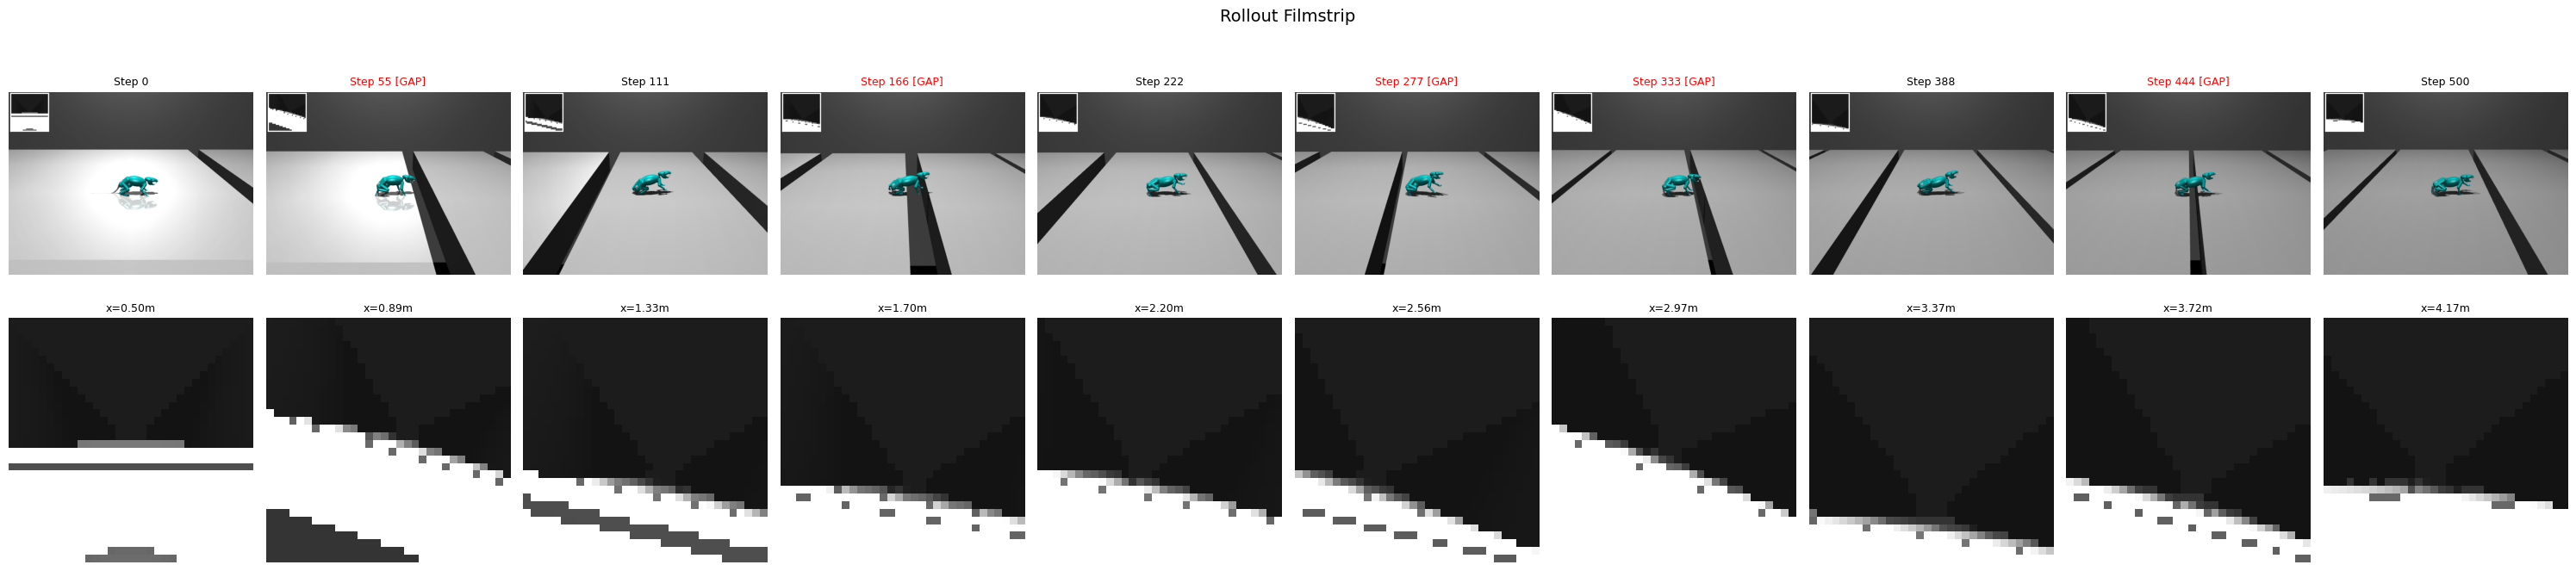

In [11]:
# Filmstrip: 10 evenly-spaced timesteps
n_show = 10
show_steps = np.linspace(0, EPISODE_LENGTH, n_show, dtype=int)

fig, axes = plt.subplots(2, n_show, figsize=(3 * n_show, 7))

for i, step in enumerate(show_steps):
    # Third-person with ego overlay
    frame = render_third_person(qpos_list[step])
    frame = overlay_ego(frame, ego_frames[step])
    axes[0, i].imshow(frame)
    is_near = in_gap_zone[step]
    color = "red" if is_near else "black"
    label = f"Step {step}" + (" [GAP]" if is_near else "")
    axes[0, i].set_title(label, fontsize=9, color=color)
    axes[0, i].axis("off")

    # Egocentric view enlarged
    ego = ego_frames[step]
    axes[1, i].imshow(
        ego[:, :, 0] if ego.shape[-1] == 1 else ego,
        cmap="gray",
        vmin=0,
        vmax=1,
    )
    axes[1, i].set_title(f"x={rodent_x_positions[step]:.2f}m", fontsize=9)
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("Third-person + ego overlay", fontsize=10)
axes[1, 0].set_ylabel("Egocentric (32x32)", fontsize=10)
plt.suptitle("Rollout Filmstrip", fontsize=14)
plt.tight_layout()
plt.show()

## Side-by-Side: Rollout + Activation Temporal Heatmaps

Left: egocentric vision kymograph. Right: CNN features, fusion MLP hiddens, latent z over time.
Vertical dashed lines mark gap crossings.

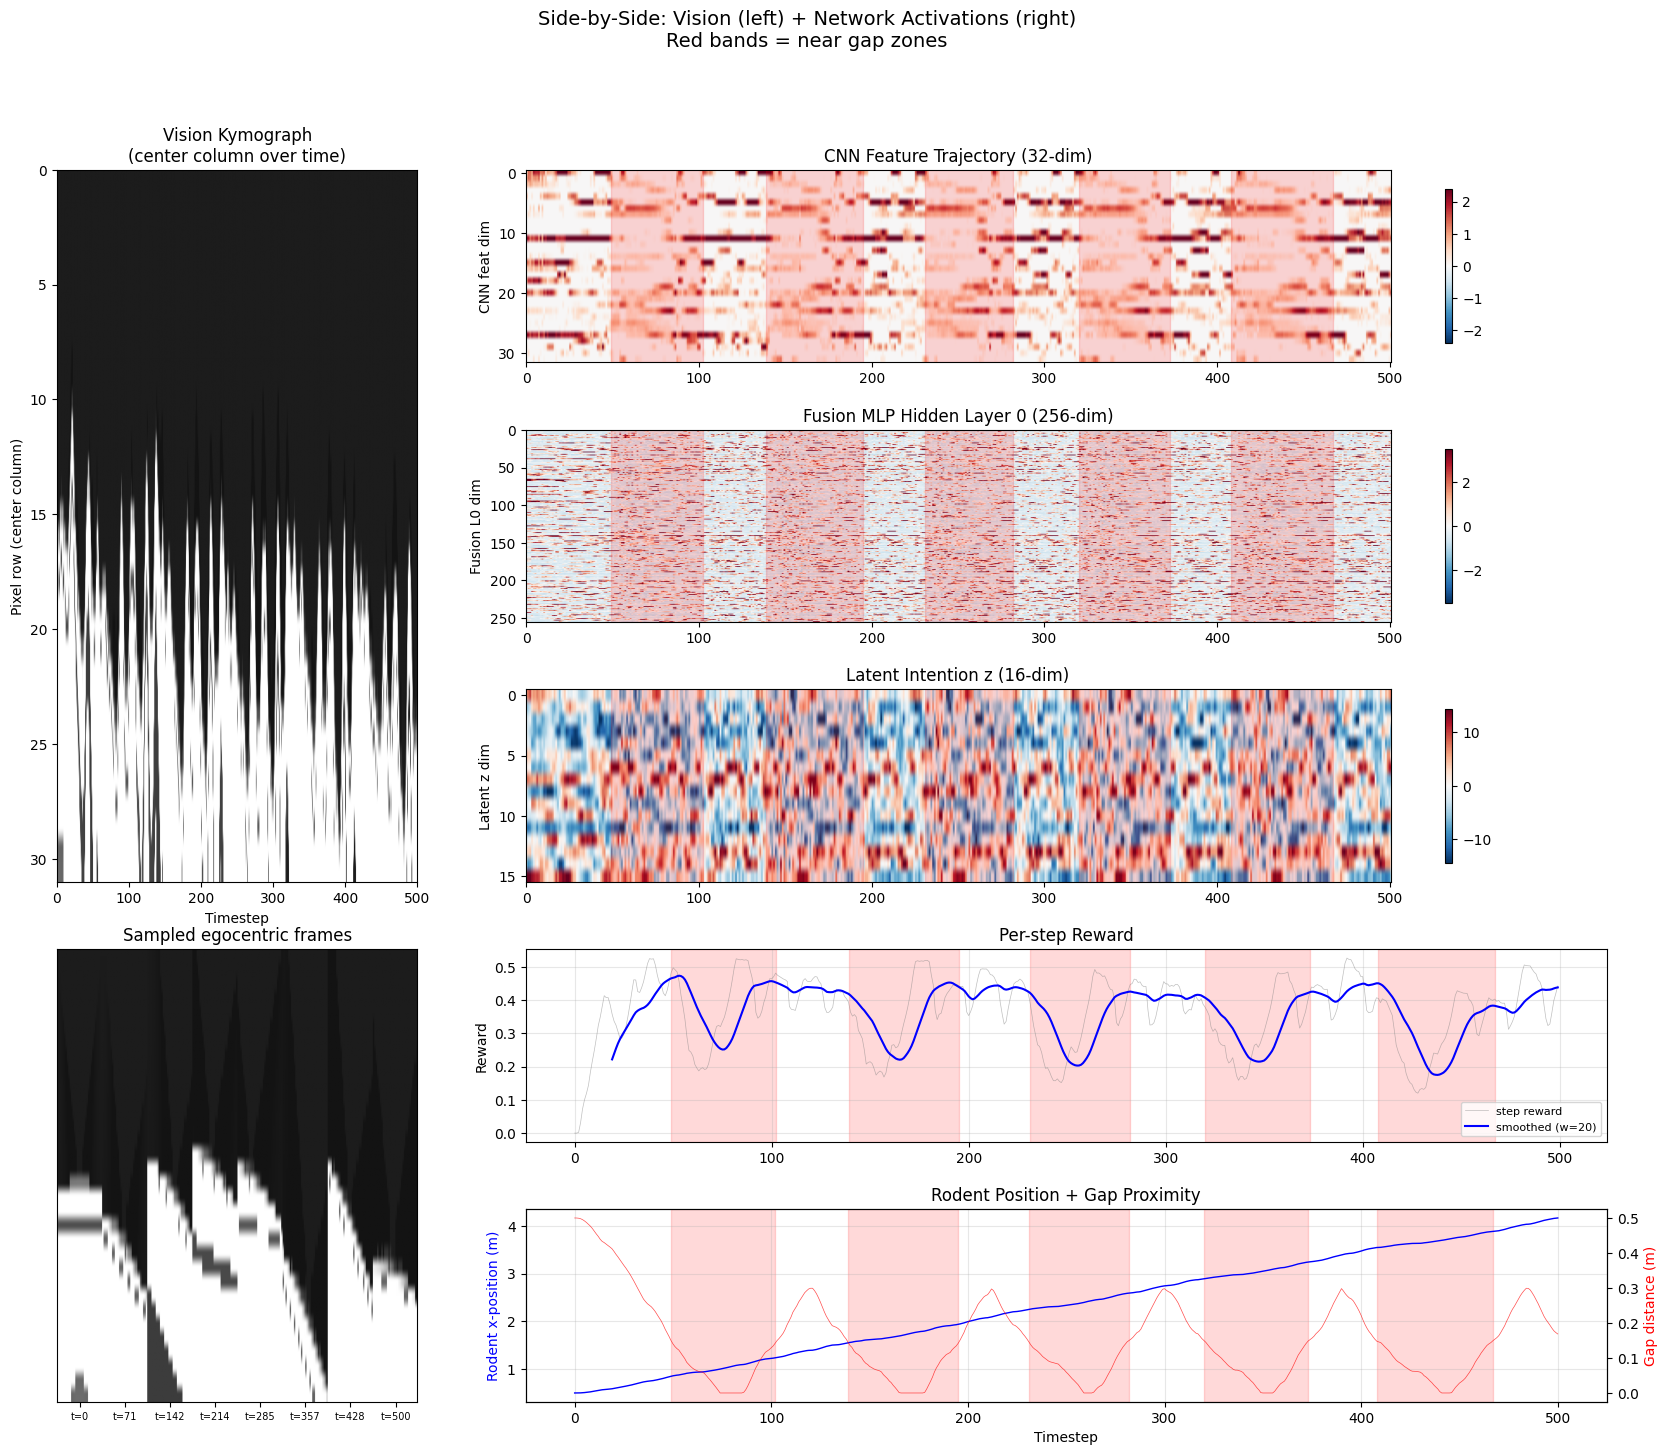

In [12]:
fig = plt.figure(figsize=(20, 16))
gs = gridspec.GridSpec(5, 2, width_ratios=[1, 3], hspace=0.35, wspace=0.15)

timesteps = np.arange(len(rodent_x_positions))

# --- Left column: Vision kymograph ---
# Extract center column of egocentric images over time
ego_array = np.array(ego_frames)  # (T+1, 32, 32, 1)
center_col = ego_array[:, :, 16, 0]  # (T+1, 32) - center vertical slice

ax_kymo = fig.add_subplot(gs[:3, 0])
ax_kymo.imshow(
    center_col.T,
    aspect="auto",
    cmap="gray",
    vmin=0,
    vmax=1,
    extent=[0, len(timesteps) - 1, 31, 0],
)
ax_kymo.set_xlabel("Timestep")
ax_kymo.set_ylabel("Pixel row (center column)")
ax_kymo.set_title("Vision Kymograph\n(center column over time)")

# Ego frames at sampled steps
ax_ego_strip = fig.add_subplot(gs[3:, 0])
n_strip = min(8, len(ego_frames))
strip_steps = np.linspace(0, len(ego_frames) - 1, n_strip, dtype=int)
strip_img = np.concatenate([ego_frames[s][:, :, 0] for s in strip_steps], axis=1)
ax_ego_strip.imshow(strip_img, cmap="gray", vmin=0, vmax=1, aspect="auto")
ax_ego_strip.set_xticks(np.arange(n_strip) * 32 + 16)
ax_ego_strip.set_xticklabels([f"t={s}" for s in strip_steps], fontsize=7)
ax_ego_strip.set_yticks([])
ax_ego_strip.set_title("Sampled egocentric frames")


def add_gap_markers(ax, gap_starts, gap_ends, rodent_x, timesteps):
    """Add vertical bands where rodent is in gap zones."""
    for gs_x, ge_x in zip(gap_starts, gap_ends):
        # Find timesteps where rodent is near this gap
        near = np.where(
            (rodent_x > gs_x - GAP_ZONE_RADIUS) & (rodent_x < ge_x + GAP_ZONE_RADIUS)
        )[0]
        if len(near) > 0:
            ax.axvspan(
                near[0],
                near[-1],
                alpha=0.15,
                color="red",
                zorder=0,
            )


# --- Right column: Activation heatmaps ---

# 1. CNN features (32-dim)
ax_cnn = fig.add_subplot(gs[0, 1])
im1 = ax_cnn.imshow(
    cnn_features_traj.T,
    aspect="auto",
    cmap="RdBu_r",
    vmin=-np.percentile(np.abs(cnn_features_traj), 98),
    vmax=np.percentile(np.abs(cnn_features_traj), 98),
)
ax_cnn.set_ylabel("CNN feat dim")
ax_cnn.set_title("CNN Feature Trajectory (32-dim)")
add_gap_markers(ax_cnn, gap_starts, gap_ends, rodent_x_positions, timesteps)
plt.colorbar(im1, ax=ax_cnn, shrink=0.8)

# 2. Fusion hidden layer 0 (256-dim)
ax_fus0 = fig.add_subplot(gs[1, 1])
im2 = ax_fus0.imshow(
    fusion0_traj.T,
    aspect="auto",
    cmap="RdBu_r",
    vmin=-np.percentile(np.abs(fusion0_traj), 98),
    vmax=np.percentile(np.abs(fusion0_traj), 98),
)
ax_fus0.set_ylabel("Fusion L0 dim")
ax_fus0.set_title("Fusion MLP Hidden Layer 0 (256-dim)")
add_gap_markers(ax_fus0, gap_starts, gap_ends, rodent_x_positions, timesteps)
plt.colorbar(im2, ax=ax_fus0, shrink=0.8)

# 3. Latent z (16-dim)
ax_z = fig.add_subplot(gs[2, 1])
im3 = ax_z.imshow(
    latent_z_traj.T,
    aspect="auto",
    cmap="RdBu_r",
    vmin=-np.percentile(np.abs(latent_z_traj), 98),
    vmax=np.percentile(np.abs(latent_z_traj), 98),
)
ax_z.set_ylabel("Latent z dim")
ax_z.set_title("Latent Intention z (16-dim)")
add_gap_markers(ax_z, gap_starts, gap_ends, rodent_x_positions, timesteps)
plt.colorbar(im3, ax=ax_z, shrink=0.8)

# 4. Reward + rodent x-position
ax_reward = fig.add_subplot(gs[3, 1])
ax_reward.plot(rewards, linewidth=0.5, alpha=0.5, color="gray", label="step reward")
window = 20
if len(rewards) > window:
    smoothed = np.convolve(rewards, np.ones(window) / window, mode="valid")
    ax_reward.plot(
        range(window - 1, len(rewards)),
        smoothed,
        linewidth=1.5,
        color="blue",
        label=f"smoothed (w={window})",
    )
add_gap_markers(ax_reward, gap_starts, gap_ends, rodent_x_positions, timesteps)
ax_reward.set_ylabel("Reward")
ax_reward.set_title("Per-step Reward")
ax_reward.legend(fontsize=8)
ax_reward.grid(True, alpha=0.3)

# 5. Gap proximity + x-position
ax_gap = fig.add_subplot(gs[4, 1])
ax_gap.plot(rodent_x_positions, linewidth=1, color="blue", label="rodent x")
ax2 = ax_gap.twinx()
ax2.plot(gap_proximity, linewidth=0.5, color="red", alpha=0.7, label="gap distance")
ax2.set_ylabel("Gap distance (m)", color="red")
add_gap_markers(ax_gap, gap_starts, gap_ends, rodent_x_positions, timesteps)
ax_gap.set_xlabel("Timestep")
ax_gap.set_ylabel("Rodent x-position (m)", color="blue")
ax_gap.set_title("Rodent Position + Gap Proximity")
ax_gap.grid(True, alpha=0.3)

plt.suptitle(
    "Side-by-Side: Vision (left) + Network Activations (right)\n"
    "Red bands = near gap zones",
    fontsize=14,
)
plt.show()

## Gap Feature Analysis: Correlate Features with Gap Proximity

Find which CNN features, fusion hidden units, and latent z dimensions are most
correlated with being near a gap.

In [13]:
# Compute correlation of each feature dimension with gap proximity
# Use inverse gap proximity (higher = closer to gap) for positive correlation
inv_gap_prox = 1.0 / (gap_proximity + 0.01)  # avoid div by 0


def compute_feature_gap_correlations(features, name):
    """Compute Pearson correlation of each feature dim with gap proximity."""
    n_dims = features.shape[1]
    correlations = np.zeros(n_dims)
    p_values = np.zeros(n_dims)
    for d in range(n_dims):
        r, p = stats.pearsonr(features[:, d], inv_gap_prox)
        correlations[d] = r
        p_values[d] = p
    return correlations, p_values


# CNN features (32-dim)
cnn_corr, cnn_pval = compute_feature_gap_correlations(cnn_features_traj, "CNN")

# Fusion layer 0 (256-dim)
fus0_corr, fus0_pval = compute_feature_gap_correlations(fusion0_traj, "Fusion0")

# Latent z (16-dim)
z_corr, z_pval = compute_feature_gap_correlations(latent_z_traj, "Latent z")


# Report top features
def report_top_features(corr, pval, name, top_k=5):
    sorted_idx = np.argsort(np.abs(corr))[::-1]
    print(f"\n=== Top {top_k} {name} features correlated with gap proximity ===")
    for rank, idx in enumerate(sorted_idx[:top_k]):
        sig = (
            "***"
            if pval[idx] < 0.001
            else "**" if pval[idx] < 0.01 else "*" if pval[idx] < 0.05 else ""
        )
        print(f"  #{rank+1}: dim {idx}, r={corr[idx]:+.4f}, p={pval[idx]:.2e} {sig}")
    return sorted_idx[:top_k]


top_cnn = report_top_features(cnn_corr, cnn_pval, "CNN", top_k=5)
top_fus0 = report_top_features(fus0_corr, fus0_pval, "Fusion L0", top_k=5)
top_z = report_top_features(z_corr, z_pval, "Latent z", top_k=5)


=== Top 5 CNN features correlated with gap proximity ===
  #1: dim 23, r=+0.6048, p=2.65e-51 ***
  #2: dim 8, r=+0.5393, p=3.72e-39 ***
  #3: dim 19, r=+0.5293, p=1.59e-37 ***
  #4: dim 3, r=+0.4164, p=1.97e-22 ***
  #5: dim 11, r=-0.4087, p=1.36e-21 ***

=== Top 5 Fusion L0 features correlated with gap proximity ===
  #1: dim 41, r=+0.5938, p=4.59e-49 ***
  #2: dim 255, r=+0.5652, p=1.24e-43 ***
  #3: dim 207, r=+0.5031, p=1.67e-33 ***
  #4: dim 58, r=+0.4345, p=1.72e-24 ***
  #5: dim 45, r=+0.4313, p=4.13e-24 ***

=== Top 5 Latent z features correlated with gap proximity ===
  #1: dim 12, r=-0.3287, p=4.32e-14 ***
  #2: dim 10, r=-0.2973, p=1.10e-11 ***
  #3: dim 2, r=-0.2404, p=5.08e-08 ***
  #4: dim 7, r=+0.1985, p=7.60e-06 ***
  #5: dim 5, r=+0.1807, p=4.74e-05 ***


## Gap-Correlated CNN Features: Enhanced Side-by-Side

The top CNN features correlated with gap proximity (by Pearson r with inverse
gap distance). This plot highlights the top 5 gap-responsive features as
individual time series alongside the full activation heatmap.

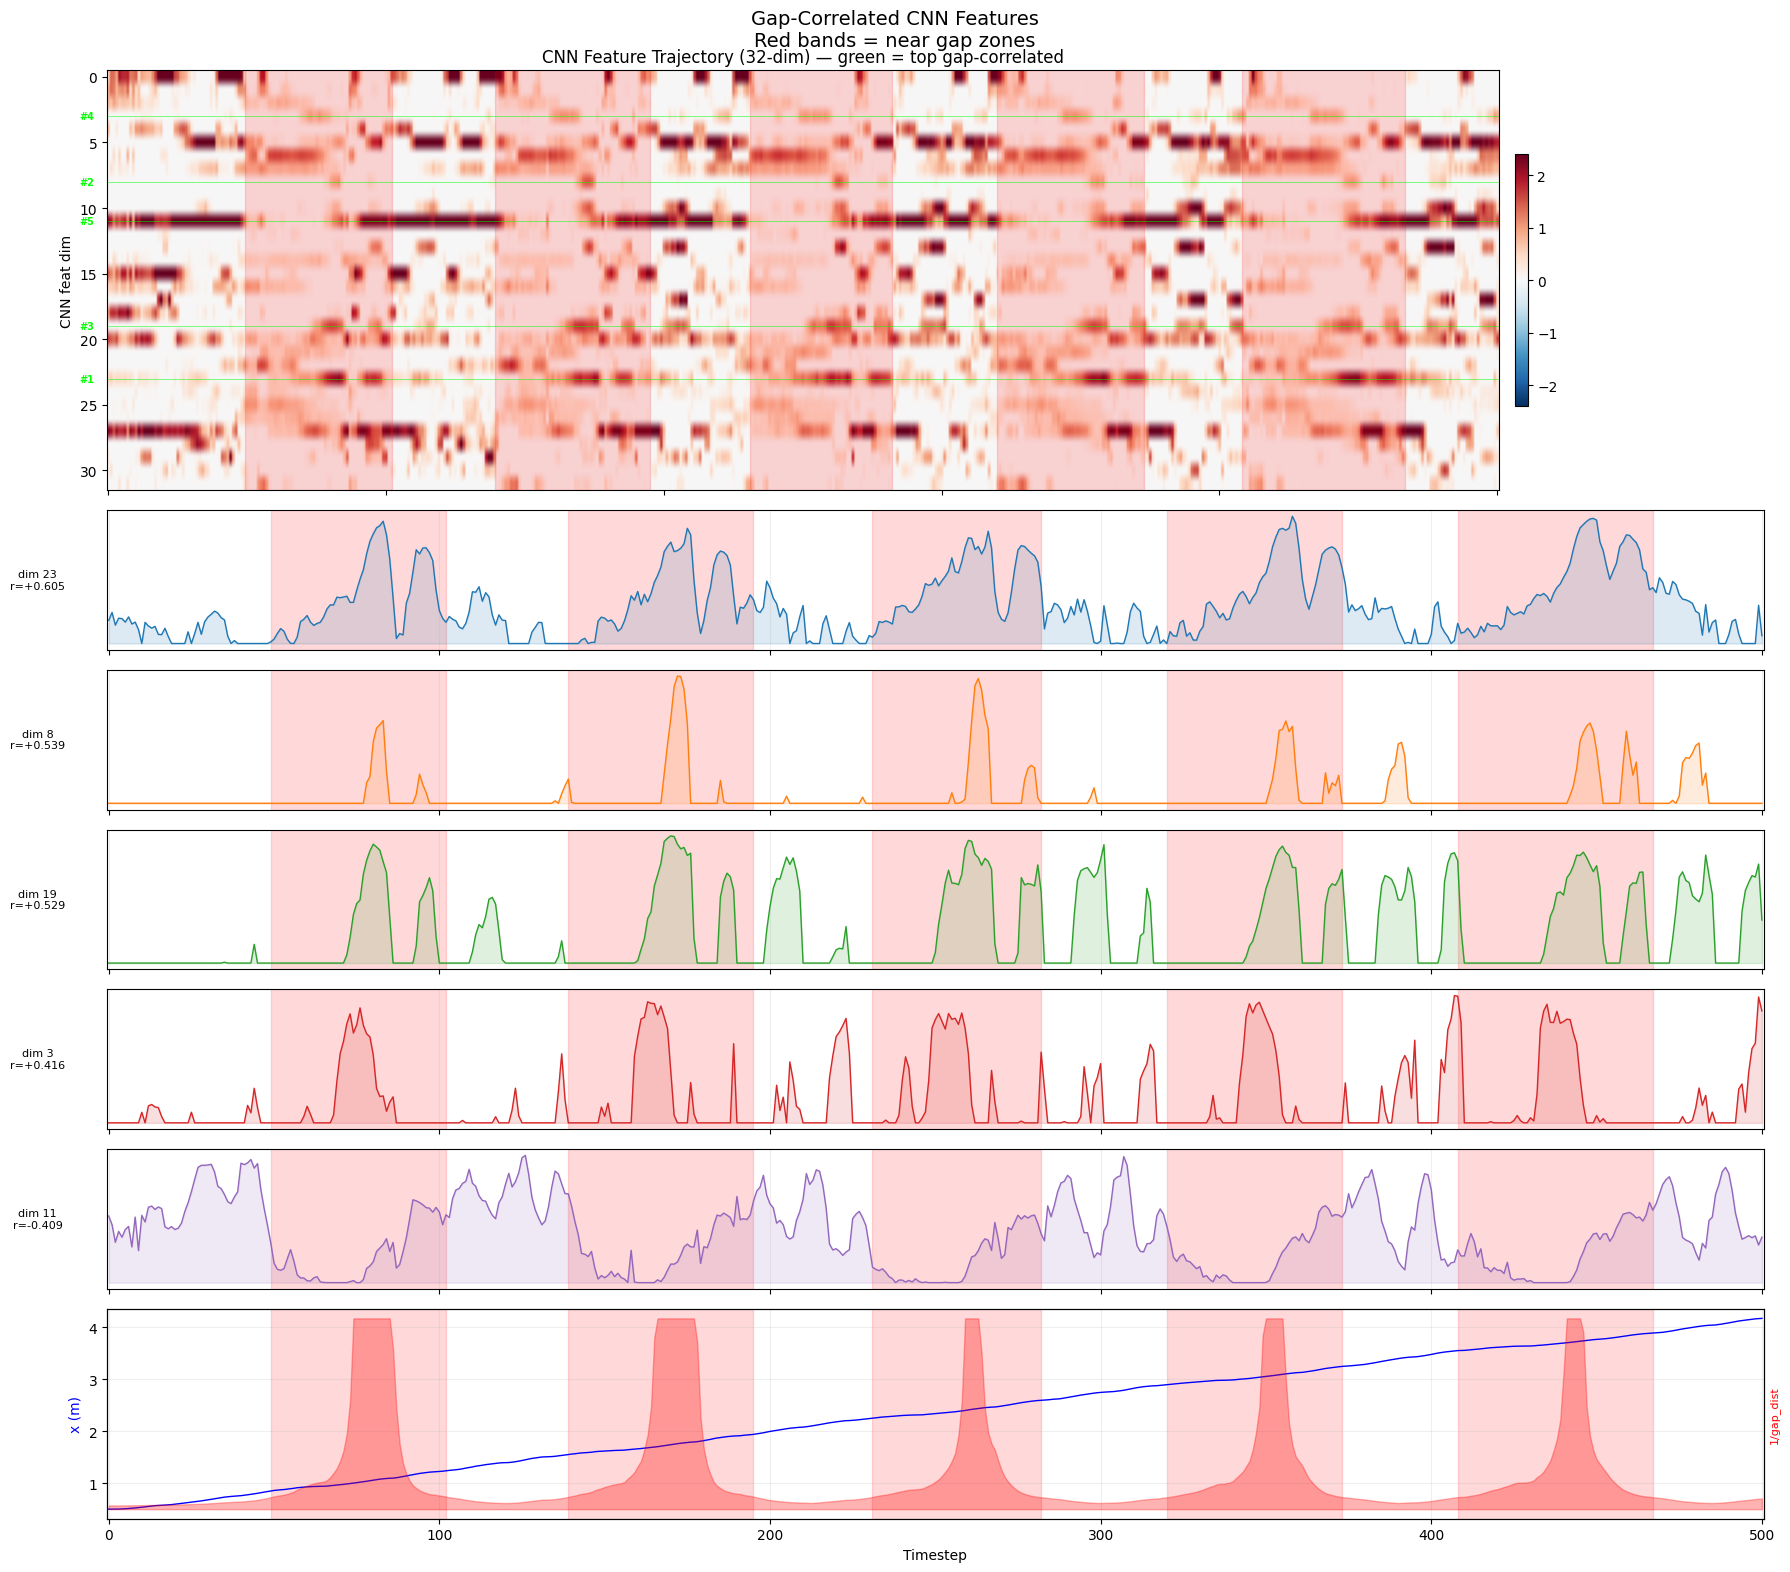

In [14]:
fig, axes = plt.subplots(
    7,
    1,
    figsize=(18, 16),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1, 1, 1, 1, 1, 1.5]},
)

# Row 0: Full CNN heatmap with top features marked
ax = axes[0]
im = ax.imshow(
    cnn_features_traj.T,
    aspect="auto",
    cmap="RdBu_r",
    vmin=-np.percentile(np.abs(cnn_features_traj), 98),
    vmax=np.percentile(np.abs(cnn_features_traj), 98),
)
add_gap_markers(ax, gap_starts, gap_ends, rodent_x_positions, timesteps)
for rank, idx in enumerate(top_cnn):
    ax.axhline(idx, color="lime", linewidth=0.5, alpha=0.7)
    ax.text(
        -5,
        idx,
        f"#{rank+1}",
        fontsize=7,
        color="lime",
        va="center",
        ha="right",
        fontweight="bold",
        clip_on=False,
    )
ax.set_ylabel("CNN feat dim")
ax.set_title("CNN Feature Trajectory (32-dim) — green = top gap-correlated")
plt.colorbar(im, ax=ax, shrink=0.6, pad=0.01)

# Rows 1-5: Individual top CNN features
colors_5 = plt.cm.tab10(np.arange(5))
for rank, idx in enumerate(top_cnn):
    ax = axes[rank + 1]
    ax.plot(cnn_features_traj[:, idx], linewidth=1, color=colors_5[rank])
    ax.fill_between(
        range(len(cnn_features_traj)),
        cnn_features_traj[:, idx],
        alpha=0.15,
        color=colors_5[rank],
    )
    add_gap_markers(ax, gap_starts, gap_ends, rodent_x_positions, timesteps)
    sign = "+" if cnn_corr[idx] > 0 else ""
    ax.set_ylabel(
        f"dim {idx}\nr={sign}{cnn_corr[idx]:.3f}",
        fontsize=8,
        rotation=0,
        labelpad=50,
        va="center",
    )
    ax.grid(True, alpha=0.2)
    ax.set_yticks([])

# Row 6: Position reference
ax = axes[6]
ax.plot(rodent_x_positions, linewidth=1, color="blue", label="rodent x")
ax2 = ax.twinx()
ax2.fill_between(
    range(len(gap_proximity)),
    1.0 / (gap_proximity + 0.01),
    alpha=0.3,
    color="red",
    label="1/gap_dist",
)
ax2.set_ylabel("1/gap_dist", color="red", fontsize=8)
ax2.set_yticks([])
add_gap_markers(ax, gap_starts, gap_ends, rodent_x_positions, timesteps)
ax.set_xlabel("Timestep")
ax.set_ylabel("x (m)", color="blue")
ax.grid(True, alpha=0.2)

plt.suptitle("Gap-Correlated CNN Features\nRed bands = near gap zones", fontsize=14)
plt.tight_layout()
plt.show()

## Video: Gap Running with CNN Feature Heatmaps

Side-by-side video showing:
- **Left:** Third-person view with egocentric overlay
- **Middle:** Egocentric image with Conv3 mean activation heatmap overlay (jet colormap)
- **Right:** Top Conv3 channel spatial activation maps (individual channels)
- **Bottom:** CNN feature norm timeline with red cursor at current frame

Red title text = rodent is near a gap zone.

In [15]:
from scipy.ndimage import zoom as scipy_zoom
from matplotlib.animation import FFMpegWriter
from IPython.display import Video, display

VIDEO_SAVE_PATH = str(CHECKPOINT_DIR.parent / "cnn_gap_rollout.mp4")

# Top conv3 channels to visualize (from spatial analysis cell)
try:
    vis_ch = list(top_channels[:6])
except NameError:
    vis_ch = list(range(6))


def nn_upscale(img, factor):
    """Nearest-neighbor upscale by integer factor."""
    return np.repeat(np.repeat(img, factor, axis=0), factor, axis=1)


# ---- Build matplotlib figure ----
fig_vid = plt.figure(figsize=(14, 5.4), dpi=100)  # 1400 x 540 px
gs_vid = gridspec.GridSpec(
    2,
    3,
    height_ratios=[6, 1],
    width_ratios=[3, 1.3, 1.3],
    wspace=0.06,
    hspace=0.25,
)

# Panel 1: Third-person view (left, large)
ax_tp = fig_vid.add_subplot(gs_vid[0, 0])
im_tp = ax_tp.imshow(np.zeros((VIDEO_HEIGHT, VIDEO_WIDTH, 3), dtype=np.uint8))
ax_tp.axis("off")
title_tp = ax_tp.set_title("", fontsize=11, fontweight="bold")

# Panel 2: Ego + CNN heatmap overlay (middle)
EGO_VIS_SIZE = 192  # 32 * 6
im_ego = ax_ego_vid = fig_vid.add_subplot(gs_vid[0, 1])
_ego_im = ax_ego_vid.imshow(np.zeros((EGO_VIS_SIZE, EGO_VIS_SIZE, 3), dtype=np.uint8))
ax_ego_vid.axis("off")
title_ego_vid = ax_ego_vid.set_title("Ego + CNN activation", fontsize=9)

# Panel 3: Conv3 channel grid (right)
ax_conv_vid = fig_vid.add_subplot(gs_vid[0, 2])
conv_grid_rows = (len(vis_ch) + 2) // 3
conv_cell = 64
_conv_im = ax_conv_vid.imshow(
    np.zeros((conv_grid_rows * conv_cell, 3 * conv_cell, 3), dtype=np.uint8)
)
ax_conv_vid.axis("off")
title_conv_vid = ax_conv_vid.set_title("Conv3 top channels", fontsize=9)

# Panel 4: Timeline (bottom, full width)
ax_timeline = fig_vid.add_subplot(gs_vid[1, :])
cnn_norm_traj = np.linalg.norm(cnn_features_traj, axis=1)
ax_timeline.fill_between(
    range(len(cnn_norm_traj)), cnn_norm_traj, alpha=0.25, color="steelblue"
)
ax_timeline.plot(
    cnn_norm_traj, linewidth=0.8, color="steelblue", label="|CNN features|"
)
# Mark gap zones on timeline
for gs_x, ge_x in zip(gap_starts, gap_ends):
    near_t = np.where(
        (rodent_x_positions > gs_x - GAP_ZONE_RADIUS)
        & (rodent_x_positions < ge_x + GAP_ZONE_RADIUS)
    )[0]
    if len(near_t) > 0:
        ax_timeline.axvspan(near_t[0], near_t[-1], alpha=0.2, color="red")
ax_timeline.set_xlim(0, len(cnn_norm_traj) - 1)
ax_timeline.set_ylim(0, cnn_norm_traj.max() * 1.1)
ax_timeline.set_yticks([])
ax_timeline.set_ylabel("|CNN|", fontsize=8)
ax_timeline.set_xlabel("Timestep", fontsize=8)
ax_timeline.legend(fontsize=7, loc="upper right")
cursor_line = ax_timeline.axvline(0, color="red", linewidth=2, zorder=10)

fig_vid.tight_layout()

# ---- Render all frames ----
print(f"Generating {EPISODE_LENGTH + 1} frames at {VIDEO_FPS} fps...")
print(f"Conv3 channels visualized: {vis_ch}")

vid_writer = FFMpegWriter(fps=VIDEO_FPS, metadata={"title": "CNN Gap Rollout"})

with vid_writer.saving(fig_vid, VIDEO_SAVE_PATH, dpi=100):
    for t in range(EPISODE_LENGTH + 1):
        # -- Third-person + ego overlay --
        tp_frame = render_third_person(qpos_list[t])
        tp_frame = overlay_ego(tp_frame, ego_frames[t], scale=4)
        im_tp.set_data(tp_frame)

        gap_d = gap_proximity[t]
        near = in_gap_zone[t]
        title_tp.set_text(
            f"Step {t}  |  x = {rodent_x_positions[t]:.2f} m  |  "
            f"gap = {gap_d:.3f} m" + ("  [NEAR GAP]" if near else "")
        )
        title_tp.set_color("red" if near else "black")

        # -- Ego + conv3 mean heatmap overlay --
        conv_acts_t = get_conv_activations(ego_frames[t])
        conv3 = conv_acts_t[-1]  # (6, 6, 32)

        ego_rgb = np.clip(ego_frames[t], 0, 1)
        if ego_rgb.shape[-1] == 1:
            ego_rgb = np.repeat(ego_rgb, 3, axis=-1)
        ego_up = nn_upscale(
            (ego_rgb * 255).astype(np.uint8), EGO_VIS_SIZE // ego_rgb.shape[0]
        )[:EGO_VIS_SIZE, :EGO_VIS_SIZE]

        heat = conv3.mean(axis=-1)  # (6, 6)
        heat_norm = heat / max(heat.max(), 1e-6)
        heat_up = scipy_zoom(heat_norm, EGO_VIS_SIZE / heat.shape[0], order=1)
        heat_up = np.clip(heat_up[:EGO_VIS_SIZE, :EGO_VIS_SIZE], 0, 1)
        heat_rgb = (plt.cm.jet(heat_up)[:, :, :3] * 255).astype(np.uint8)

        blended = np.clip(
            ego_up.astype(float) * 0.55 + heat_rgb.astype(float) * 0.45, 0, 255
        ).astype(np.uint8)
        _ego_im.set_data(blended)
        title_ego_vid.set_text(f"Ego + CNN heat" + (" [NEAR GAP]" if near else ""))
        title_ego_vid.set_color("red" if near else "black")

        # -- Conv3 individual channel grid --
        cols_n = 3
        rows_n = (len(vis_ch) + cols_n - 1) // cols_n
        grid = np.zeros((rows_n * conv_cell, cols_n * conv_cell, 3), dtype=np.uint8)
        for idx, ch in enumerate(vis_ch):
            r, c = divmod(idx, cols_n)
            act = conv3[:, :, ch]
            act_n = np.clip(act / max(act.max(), 1e-6), 0, 1)
            act_up = scipy_zoom(act_n, conv_cell / act.shape[0], order=1)
            act_up = np.clip(act_up[:conv_cell, :conv_cell], 0, 1)
            colored = (plt.cm.viridis(act_up)[:, :, :3] * 255).astype(np.uint8)
            grid[
                r * conv_cell : (r + 1) * conv_cell, c * conv_cell : (c + 1) * conv_cell
            ] = colored
        _conv_im.set_data(grid)

        # -- Update timeline cursor --
        cursor_line.set_xdata([t, t])

        # -- Write frame --
        vid_writer.grab_frame()

        if (t + 1) % 100 == 0:
            print(f"  {t + 1}/{EPISODE_LENGTH + 1} frames rendered")

plt.close(fig_vid)
print(f"\nVideo saved: {VIDEO_SAVE_PATH}")
print(f"Duration: {(EPISODE_LENGTH + 1) / VIDEO_FPS:.1f} seconds at {VIDEO_FPS} fps")

/tmp/ipykernel_765781/36444331.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_vid.tight_layout()


Generating 501 frames at 50 fps...
Conv3 channels visualized: [0, 1, 2, 3, 4, 5]
  100/501 frames rendered
  200/501 frames rendered
  300/501 frames rendered
  400/501 frames rendered
  500/501 frames rendered

Video saved: /home/talmolab/Desktop/SalkResearch/vnl-playground/highlvl_checkpoints/cnn_gap_rollout.mp4
Duration: 10.0 seconds at 50 fps


In [ ]:
# Display the video inline in the notebook
display(Video(VIDEO_SAVE_PATH, embed=True, width=960))

## Video: Latent z PCA Trajectory

3D PCA of the 16-dim latent intention vector over the rollout.

- **Left:** Third-person view with egocentric vision overlay
- **Right:** 3D PCA scatter (top 3 PCs). Current timestep highlighted with
  large marker. Fading trail of the past 50 timesteps. Points colored
  red (near gap) vs blue (far from gap).

In [17]:
from sklearn.decomposition import PCA

# Fit PCA
pca_z = PCA(n_components=3)
z_pca = pca_z.fit_transform(latent_z_traj)
print(f"Latent z PCA explained variance: {pca_z.explained_variance_ratio_}")
print(f"Total explained: {pca_z.explained_variance_ratio_.sum():.3f}")

# Fixed axis limits
pad_frac = 0.1
z_mins = z_pca.min(axis=0) - pad_frac * np.ptp(z_pca, axis=0)
z_maxs = z_pca.max(axis=0) + pad_frac * np.ptp(z_pca, axis=0)

TRAIL_LEN = 50
VIDEO_SAVE_PATH_PCA_Z = str(CHECKPOINT_DIR.parent / "latent_z_pca_trajectory.mp4")

fig_pca = plt.figure(figsize=(16, 6), dpi=100)
gs_pca = gridspec.GridSpec(1, 2, width_ratios=[1, 1.2], wspace=0.05)

ax_left = fig_pca.add_subplot(gs_pca[0, 0])
im_left = ax_left.imshow(np.zeros((VIDEO_HEIGHT, VIDEO_WIDTH, 3), dtype=np.uint8))
ax_left.axis("off")
title_left = ax_left.set_title("", fontsize=10, fontweight="bold")

ax_right = fig_pca.add_subplot(gs_pca[0, 1], projection="3d")

print(f"Generating latent z PCA video ({EPISODE_LENGTH + 1} frames)...")
vid_writer = FFMpegWriter(fps=VIDEO_FPS, metadata={"title": "Latent z PCA"})

with vid_writer.saving(fig_pca, VIDEO_SAVE_PATH_PCA_Z, dpi=100):
    for t in range(EPISODE_LENGTH + 1):
        # Left: third-person + ego overlay
        tp_frame = render_third_person(qpos_list[t])
        tp_frame = overlay_ego(tp_frame, ego_frames[t], scale=4)
        im_left.set_data(tp_frame)
        near = in_gap_zone[t]
        title_left.set_text(
            f"Step {t}  |  x={rodent_x_positions[t]:.2f}m"
            + ("  [NEAR GAP]" if near else "")
        )
        title_left.set_color("red" if near else "black")

        # Right: 3D PCA scatter
        ax_right.cla()
        ax_right.set_xlim(z_mins[0], z_maxs[0])
        ax_right.set_ylim(z_mins[1], z_maxs[1])
        ax_right.set_zlim(z_mins[2], z_maxs[2])
        ax_right.set_xlabel(
            f"PC1 ({pca_z.explained_variance_ratio_[0]:.0%})", fontsize=8
        )
        ax_right.set_ylabel(
            f"PC2 ({pca_z.explained_variance_ratio_[1]:.0%})", fontsize=8
        )
        ax_right.set_zlabel(
            f"PC3 ({pca_z.explained_variance_ratio_[2]:.0%})", fontsize=8
        )
        ax_right.set_title("Latent z \u2014 Top 3 PCs", fontsize=10)
        ax_right.view_init(elev=25, azim=30)

        # All past points as faint context
        if t > 0:
            ax_right.scatter(
                z_pca[: t + 1, 0],
                z_pca[: t + 1, 1],
                z_pca[: t + 1, 2],
                c=["red" if g else "steelblue" for g in in_gap_zone[: t + 1]],
                s=3,
                alpha=0.08,
            )

        # Fading trail
        t_start = max(0, t - TRAIL_LEN)
        trail = z_pca[t_start : t + 1]
        trail_gap = in_gap_zone[t_start : t + 1]
        n_trail = len(trail)
        if n_trail > 1:
            alphas = np.linspace(0.05, 0.8, n_trail)
            sizes = np.linspace(8, 40, n_trail)
            for i in range(n_trail):
                color = "red" if trail_gap[i] else "dodgerblue"
                ax_right.scatter(
                    trail[i, 0],
                    trail[i, 1],
                    trail[i, 2],
                    c=color,
                    s=sizes[i],
                    alpha=alphas[i],
                    edgecolors="none",
                )
            for i in range(1, n_trail):
                seg_alpha = float(alphas[i])
                color = "red" if trail_gap[i] else "dodgerblue"
                ax_right.plot(
                    trail[i - 1 : i + 1, 0],
                    trail[i - 1 : i + 1, 1],
                    trail[i - 1 : i + 1, 2],
                    color=color,
                    alpha=seg_alpha * 0.6,
                    linewidth=1.5,
                )

        # Current point
        cur_color = "red" if near else "dodgerblue"
        ax_right.scatter(
            z_pca[t, 0],
            z_pca[t, 1],
            z_pca[t, 2],
            c=cur_color,
            s=200,
            edgecolors="black",
            linewidths=1.5,
            zorder=10,
        )

        vid_writer.grab_frame()
        if (t + 1) % 100 == 0:
            print(f"  {t+1}/{EPISODE_LENGTH+1} frames")

plt.close(fig_pca)
print(f"Video saved: {VIDEO_SAVE_PATH_PCA_Z}")

Latent z PCA explained variance: [0.18666498 0.13578391 0.10850084]
Total explained: 0.431
Generating latent z PCA video (501 frames)...
  100/501 frames
  200/501 frames
  300/501 frames
  400/501 frames
  500/501 frames
Video saved: /home/talmolab/Desktop/SalkResearch/vnl-playground/highlvl_checkpoints/latent_z_pca_trajectory.mp4


In [ ]:
display(Video(VIDEO_SAVE_PATH_PCA_Z, embed=True, width=960))

## Video: CNN Features PCA Trajectory

3D PCA of the 32-dim CNN feature vector over the rollout.
Same format as latent z PCA: left = rollout, right = 3D PCA with
fading trail and gap coloring.

In [19]:
# Fit PCA on CNN features
pca_cnn = PCA(n_components=3)
cnn_pca = pca_cnn.fit_transform(cnn_features_traj)
print(f"CNN features PCA explained variance: {pca_cnn.explained_variance_ratio_}")
print(f"Total explained: {pca_cnn.explained_variance_ratio_.sum():.3f}")

# Fixed axis limits
pad_frac = 0.1
cnn_mins = cnn_pca.min(axis=0) - pad_frac * np.ptp(cnn_pca, axis=0)
cnn_maxs = cnn_pca.max(axis=0) + pad_frac * np.ptp(cnn_pca, axis=0)

TRAIL_LEN = 50
VIDEO_SAVE_PATH_PCA_CNN = str(CHECKPOINT_DIR.parent / "cnn_features_pca_trajectory.mp4")

fig_pca = plt.figure(figsize=(16, 6), dpi=100)
gs_pca = gridspec.GridSpec(1, 2, width_ratios=[1, 1.2], wspace=0.05)

ax_left = fig_pca.add_subplot(gs_pca[0, 0])
im_left = ax_left.imshow(np.zeros((VIDEO_HEIGHT, VIDEO_WIDTH, 3), dtype=np.uint8))
ax_left.axis("off")
title_left = ax_left.set_title("", fontsize=10, fontweight="bold")

ax_right = fig_pca.add_subplot(gs_pca[0, 1], projection="3d")

print(f"Generating CNN features PCA video ({EPISODE_LENGTH + 1} frames)...")
vid_writer = FFMpegWriter(fps=VIDEO_FPS, metadata={"title": "CNN Features PCA"})

with vid_writer.saving(fig_pca, VIDEO_SAVE_PATH_PCA_CNN, dpi=100):
    for t in range(EPISODE_LENGTH + 1):
        # Left: third-person + ego overlay
        tp_frame = render_third_person(qpos_list[t])
        tp_frame = overlay_ego(tp_frame, ego_frames[t], scale=4)
        im_left.set_data(tp_frame)
        near = in_gap_zone[t]
        title_left.set_text(
            f"Step {t}  |  x={rodent_x_positions[t]:.2f}m"
            + ("  [NEAR GAP]" if near else "")
        )
        title_left.set_color("red" if near else "black")

        # Right: 3D PCA scatter
        ax_right.cla()
        ax_right.set_xlim(cnn_mins[0], cnn_maxs[0])
        ax_right.set_ylim(cnn_mins[1], cnn_maxs[1])
        ax_right.set_zlim(cnn_mins[2], cnn_maxs[2])
        ax_right.set_xlabel(
            f"CNN PC1 ({pca_cnn.explained_variance_ratio_[0]:.0%})", fontsize=8
        )
        ax_right.set_ylabel(
            f"CNN PC2 ({pca_cnn.explained_variance_ratio_[1]:.0%})", fontsize=8
        )
        ax_right.set_zlabel(
            f"CNN PC3 ({pca_cnn.explained_variance_ratio_[2]:.0%})", fontsize=8
        )
        ax_right.set_title("CNN Features \u2014 Top 3 PCs", fontsize=10)
        ax_right.view_init(elev=25, azim=30)

        # All past points as faint context
        if t > 0:
            ax_right.scatter(
                cnn_pca[: t + 1, 0],
                cnn_pca[: t + 1, 1],
                cnn_pca[: t + 1, 2],
                c=["red" if g else "steelblue" for g in in_gap_zone[: t + 1]],
                s=3,
                alpha=0.08,
            )

        # Fading trail
        t_start = max(0, t - TRAIL_LEN)
        trail = cnn_pca[t_start : t + 1]
        trail_gap = in_gap_zone[t_start : t + 1]
        n_trail = len(trail)
        if n_trail > 1:
            alphas = np.linspace(0.05, 0.8, n_trail)
            sizes = np.linspace(8, 40, n_trail)
            for i in range(n_trail):
                color = "red" if trail_gap[i] else "dodgerblue"
                ax_right.scatter(
                    trail[i, 0],
                    trail[i, 1],
                    trail[i, 2],
                    c=color,
                    s=sizes[i],
                    alpha=alphas[i],
                    edgecolors="none",
                )
            for i in range(1, n_trail):
                seg_alpha = float(alphas[i])
                color = "red" if trail_gap[i] else "dodgerblue"
                ax_right.plot(
                    trail[i - 1 : i + 1, 0],
                    trail[i - 1 : i + 1, 1],
                    trail[i - 1 : i + 1, 2],
                    color=color,
                    alpha=seg_alpha * 0.6,
                    linewidth=1.5,
                )

        # Current point
        cur_color = "red" if near else "dodgerblue"
        ax_right.scatter(
            cnn_pca[t, 0],
            cnn_pca[t, 1],
            cnn_pca[t, 2],
            c=cur_color,
            s=200,
            edgecolors="black",
            linewidths=1.5,
            zorder=10,
        )

        vid_writer.grab_frame()
        if (t + 1) % 100 == 0:
            print(f"  {t+1}/{EPISODE_LENGTH+1} frames")

plt.close(fig_pca)
print(f"Video saved: {VIDEO_SAVE_PATH_PCA_CNN}")

CNN features PCA explained variance: [0.30920666 0.24001636 0.13940698]
Total explained: 0.689
Generating CNN features PCA video (501 frames)...
  100/501 frames
  200/501 frames
  300/501 frames
  400/501 frames
  500/501 frames
Video saved: /home/talmolab/Desktop/SalkResearch/vnl-playground/highlvl_checkpoints/cnn_features_pca_trajectory.mp4


In [ ]:
display(Video(VIDEO_SAVE_PATH_PCA_CNN, embed=True, width=960))